In [262]:
import torch
import matplotlib.pyplot as plt
import numpy as np

In [369]:
N = 10000
radius = 5
epsilon = 0.2

In [370]:
xs = np.linspace(-radius, radius, N)
ys_original = np.sqrt(25 - xs**2)

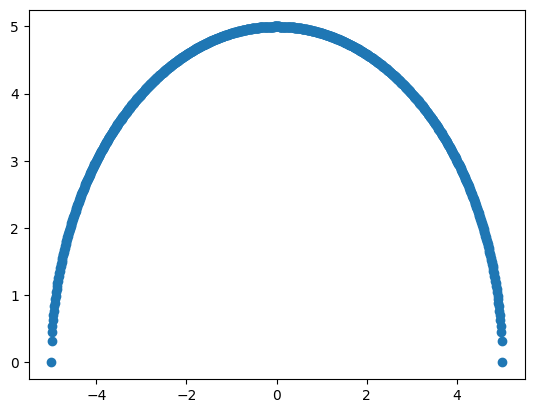

In [371]:
# (xs, ys_original) are the points on the circle
plt.scatter(xs, ys_original)

In [ ]:
# lets add some noice to ys_original so that few points will be outside the circle
noise = np.random.normal(loc=0, scale=1, size=ys_original.shape)
ys = ys_original + noise 

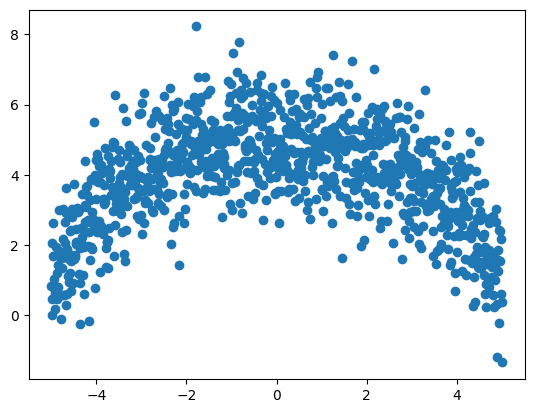

In [375]:
plt.scatter(xs, ys)

In [376]:
def distance(point, radius):
    x, y = point
    distance_from_origin = np.sqrt(y**2 + x**2)
    distance_from_curve = abs(np.sqrt(y**2 + x**2) - radius)
    return distance_from_curve

In [377]:
# lets mark these points xs, ys based on whether they are very close to the circle or not
# if they are very close to circle means if the ys is very close to the corrsponding ys_original
# we mark it as 1 otherwise we mark it as 0
samples = []
for x, y in zip(xs, ys):
    if distance((x, y), radius) < epsilon:
        samples.append([x, y, 1])
    else:
        samples.append([x, y, 0])

samples = np.array(samples)

In [378]:
points_on_circle = samples[samples[:,2] == 1]
points_off_circle = samples[samples[:,2] != 1]

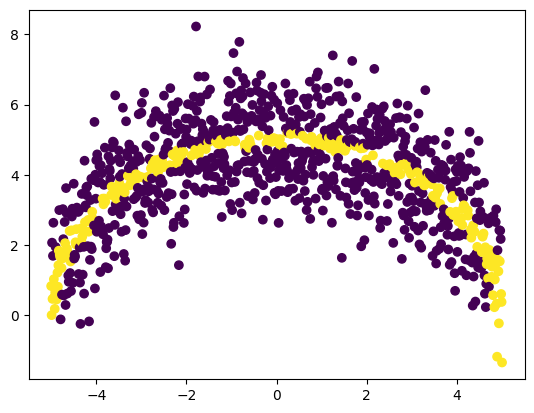

In [379]:
plt.scatter(samples[:, 0], samples[:, 1], c=samples[:, 2])

In [380]:
positive_samples = samples[samples[:, 2] == 1]
negative_samples = samples[samples[:, 2] == 0]

In [381]:
np.random.shuffle(negative_samples)
negative_samples_sub = negative_samples[:int(len(positive_samples)*0.2)]

In [382]:
train_samples = np.concatenate((positive_samples, negative_samples_sub))

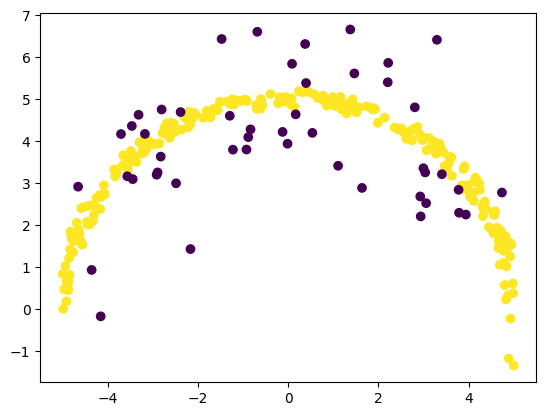

In [383]:
plt.scatter(train_samples[:, 0], train_samples[:, 1], c=train_samples[:, 2])

In [384]:
np.random.shuffle(train_samples)
train_samples[:2]

array([[-2.08708709,  4.67256629,  1.        ],
       [ 2.80780781,  4.80432092,  0.        ]])

In [385]:
train_samples = np.array(train_samples)
XS = train_samples[:, [0, 1]]
Y = train_samples[:, 2]

In [386]:
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch import nn

In [387]:
class CircleDataset(Dataset):
    def __init__(self, inputs, labels):
        super().__init__()
        self.inputs = torch.from_numpy(inputs).float()
        self.labels = torch.from_numpy(Y).unsqueeze(1).float()
    
    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]
        

In [388]:
dataset = CircleDataset(XS, Y)

In [389]:
dataloader = DataLoader(dataset, batch_size=10, shuffle=True, drop_last=True)

In [390]:
data_iter = iter(dataloader)
inputs, labels = next(data_iter)
print(inputs, labels)

tensor([[ 4.8198,  1.7325],
        [-1.6567,  4.7684],
        [-4.9099,  0.6557],
        [ 2.6376,  4.0870],
        [ 2.7477,  4.0176],
        [-2.2072,  4.6955],
        [-1.2362,  4.9960],
        [ 0.3153,  5.1633],
        [-0.9760,  4.9880],
        [-3.1181,  4.0199]]) tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]])


In [391]:
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        input_layer = nn.Linear(2, 16)
        hidden_layer = nn.Linear(16, 16)
        output_layer = nn.Linear(16, 1)
        self.network = nn.Sequential(input_layer, nn.ReLU(), hidden_layer, nn.ReLU(), output_layer)
    
    def forward(self, x):
        return self.network(x)

In [392]:
model = CircleModel()

In [393]:
def is_on_circle(x, y, debug=False):
    inputs = torch.tensor([x, y]).unsqueeze(0).float()
    with torch.no_grad():
        logit = model(inputs)
        prob = torch.sigmoid(logit).item()

    if debug:
        print(f"Probability {prob * 100:.2f} %")
    
    if prob > 0.95:
        return True
    else:
        return False

In [394]:
is_on_circle(0,5, True)

Probability 41.36 %


False

In [395]:
# Training

loss_function = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epoches = 1000

for epoch in range(1, epoches + 1):
    model.train()
    lossess = []
    
    # process each batch of inputs
    for idx, (inputs, labels) in enumerate(dataloader):
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        lossess.append(loss.item())
        optimizer.step()
    
    # Print progress
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch}/{epoches}], Avg Loss Per epoch: {np.average(lossess):.4f}")
    

Epoch [99/1000], Avg Loss Per epoch: 0.4109
Epoch [199/1000], Avg Loss Per epoch: 0.2286
Epoch [299/1000], Avg Loss Per epoch: 0.1178
Epoch [399/1000], Avg Loss Per epoch: 0.0577
Epoch [499/1000], Avg Loss Per epoch: 0.0548
Epoch [599/1000], Avg Loss Per epoch: 0.0428
Epoch [699/1000], Avg Loss Per epoch: 0.0875
Epoch [799/1000], Avg Loss Per epoch: 0.0614
Epoch [899/1000], Avg Loss Per epoch: 0.0432
Epoch [999/1000], Avg Loss Per epoch: 0.1518


In [396]:
is_on_circle(0, 5, True)

Probability 99.97 %


True

In [397]:
# Training sample acuracy
total = 0
success = 0
for x, y, actual in train_samples:
    actual = True if actual > 0 else False
    total += 1
    if is_on_circle(x, y) == actual:
        success += 1

print(f"Accuracy {success/total*100:.2f}")

Accuracy 95.52


In [398]:
# Whole sample accuracy
total = 0
success = 0
for x, y, actual in samples:
    actual = True if actual > 0 else False
    total += 1
    if is_on_circle(x, y) == actual:
        success += 1

print(f"Accuracy {success/total*100:.2f}")

Accuracy 87.80
